## Ahmad 
## 2610 4004

## lab 11

## Information Security 

___

#### TASK 1 — Secure Steganography System (Sender & Receiver)
Sender Side
1. Accept: 
o Cover image 
o Secret message 
2. Compute: 
o Message length (in bits) 
o Maximum embedding capacity of the image 
3. Validate: 
o Ensure message length does not exceed image capacity 
4. Embed message: 
o Use LSB technique 
o Restrict embedding to a single color channel
5. Apply security: 
o Accept a numeric key 
o Use the key to determine embedding order (randomized positions) 
6. Generate: 
o Stego-image 


Receiver Side


1. Accept: 
o Stego-image 
o Same numeric key 
2. Extract: 
o Message length 
o Hidden message 
3. Compute: 
o Maximum capacity of the image 
4. Validate: 
o If extracted message length exceeds capacity, print:
“Error: Message length is invalid. Image may be corrupted.”
5. Ensure: 
o Correct reconstruction of original message 
o Proper handling of invalid or corrupted inputs

----- STEGANOGRAPHY SYSTEM -----
Message: how are you
Message (binary): 0110100001101111011101110010000001100001011100100110010100100000011110010110111101110101
Total bits: 120 | Capacity: 750261
Stego saved: stego.png
Recovered: how are you
Match: Yes


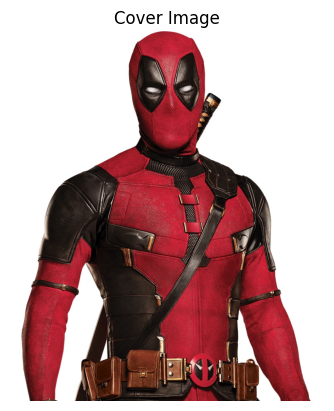

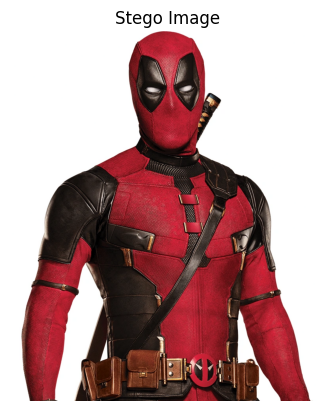

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
import sys

# text to bits
def to_bits(text):
    return ''.join(format(ord(c), '08b') for c in text)


# bits to text
def to_text(bits):
    return ''.join(chr(int(bits[i:i+8], 2)) for i in range(0, len(bits), 8))

# Sender side
def embed_message(image_path, message, key, channel=0):
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w, _ = img.shape
    total = h * w

    msg_bits = to_bits(message)
    header = format(len(msg_bits), "032b")
    bits = header + msg_bits

    print("Message:", message)
    print("Message (binary):", msg_bits)
    print("Total bits:", len(bits), "| Capacity:", total)

    if len(bits) > total:
        print("Messageis  too large")
        sys.exit()

    pos = list(range(total))
    random.seed(key)
    random.shuffle(pos)

    flat = img[:, :, channel].flatten()

    for i in range(len(bits)):
        flat[pos[i]] = (flat[pos[i]] & 0xFE) | int(bits[i])

    img[:, :, channel] = flat.reshape(h, w)
    return img



# recivever side
def extract_message(stego_path, key, channel=0):
    img = np.array(Image.open(stego_path).convert("RGB"))
    h, w, _ = img.shape
    total = h * w

    pos = list(range(total))
    random.seed(key)
    random.shuffle(pos)

    flat = img[:, :, channel].flatten()

    header = "".join(str(flat[pos[i]] & 1) for i in range(32))
    msg_len = int(header, 2)

    if msg_len > total:
        print(" Error: Image may be corrupted")
        sys.exit()

    bits = "".join(str(flat[pos[i]] & 1) for i in range(32, 32 + msg_len))
    return to_text(bits)


# to show images
def show_images(cover_path, stego_array):
    cover = np.array(Image.open(cover_path).convert("RGB"))

    plt.figure()
    plt.imshow(cover)
    plt.title("Cover Image")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(stego_array)
    plt.title("Stego Image")
    plt.axis("off")
    plt.show()


# main body from here
COVER = input("Enter Cover Image Path : ")
MESSAGE = input("Enter Message : ")
KEY = int(input("Enter Key : "))
OUT = "stego.png"
CHANNEL = int(input("Enter Channel (0=Red, 1=Green, 2=Blue)"))  # 0=Red, 1=Green, 2=Blue

print("----- STEGANOGRAPHY SYSTEM -----")

# Sender
stego = embed_message(COVER, MESSAGE, KEY, CHANNEL)
Image.fromarray(stego).save(OUT)
print("Stegno saved:", OUT)

# Receiver
recovered = extract_message(OUT, KEY, CHANNEL)
print("Recovered:", recovered)

print("Match:", "Yes" if recovered == MESSAGE else "No")

# Show images inline
show_images(COVER, stego)


___

### TASK 2

Hash Functions
TASK 2 — Hash Generation and Verification (Sender & Receiver)
Sender Side
1. Accept: 
- Input (text or file) 
2. Compute: 
-  Hash using a secure algorithm (e.g., SHA-256) 
3. Generate: 
-  Hash value to be transmitted/stored

### Sender side

In [3]:
import hashlib

def hash_text(message):
    h = hashlib.sha256()          
    h.update(message.encode())    
    return h.hexdigest()          


# 2. hash for file input
def hash_file(file_path):
    h = hashlib.sha256()
    
    with open(file_path, "rb") as f:
        data = f.read()
        h.update(data)
    
    return h.hexdigest()


choice = input("Enter 1 for text, 2 for file: ")

if choice == "1":
    msg = input("Enter message: ")
    result = hash_text(msg)
    print("message : ", msg)
    print("Hash value:", result)

elif choice == "2":
    path = input("Enter file path: ")
    result = hash_file(path)
    print("file : ",path)
    print("Hash value:", result)

else:
    print("Invalid choice")

message :  how are you
Hash value: 0b9a11ae035c536dd0c676ff39482bf7996dc76cda7a31cac89626e71517ab68


### Reciever side

In [2]:
import hashlib


def hash_text(message):
    h = hashlib.sha256()          
    h.update(message.encode())    
    return h.hexdigest()          

# for file
def hash_file(file_path):
    h = hashlib.sha256()
    
    with open(file_path, "rb") as f:
        data = f.read()
        h.update(data)
    
    return h.hexdigest()


# verify
def verify_hash(original_hash, new_hash):
    if original_hash == new_hash:
        print("Hashes Match (Data is correct)")
    else:
        print("Mismatch (Data is Modified)")



choice = input("Enter 1 for text, 2 for file: ")

original_hash = input("Enter original hash: ")

if choice == "1":
    received_text = input("Enter received text: ")
    new_hash = hash_text(received_text)
    verify_hash(original_hash, new_hash)

elif choice == "2":
    file_path = input("Enter received file path: ")
    new_hash = hash_file(file_path)
    verify_hash(original_hash, new_hash)

else:
    print("Invalid choice")

Mismatch (Data is Modified)


___

### TASK 3

#### Avalanche Effect Analysis
Write a program that:
1. Takes two nearly identical inputs 
2. Computes hash values using one or more algorithms 
3. Compares: 
o Differences between hash outputs 
4. Displays: 
o Both hash values 
o Difference count 
5. Interprets: 
o Effect of small input change on hash output

In [4]:
import hashlib


# 1. create hash
def get_hash(text):
    h = hashlib.sha256()
    h.update(text.encode())
    return h.hexdigest()


# 2. convert hex hash to binary
def hex_to_bin(hex_str):
    return bin(int(hex_str, 16))[2:].zfill(256)


# 3. count bit differences
def count_difference(bin1, bin2):
    count = 0
    for i in range(len(bin1)):
        if bin1[i] != bin2[i]:
            count += 1
    return count


# 4. avalanche analysis
def avalanche_analysis(input1, input2):
    
    hash1 = get_hash(input1)
    hash2 = get_hash(input2)

    bin1 = hex_to_bin(hash1)
    bin2 = hex_to_bin(hash2)

    diff = count_difference(bin1, bin2)

    print("\n--- HASH 1 ---")
    print(hash1)

    print("\n--- HASH 2 ---")
    print(hash2)

    print("\n--- DIFFERENCE ---")
    print("Bit differences:", diff, "out of 256")

    print("\n--- INTERPRETATION ---")
    
    if diff > 128:
        print("Strong Avalanche Effect")
    elif diff > 64:
        print("Moderate Avalanche Effect")
    else:
        print("Weak Avalanche Effect ")


text1 = input("Enter first input: ")
text2 = input("Enter second input (slightly changed): ")

avalanche_analysis(text1, text2)


--- HASH 1 ---
2cf24dba5fb0a30e26e83b2ac5b9e29e1b161e5c1fa7425e73043362938b9824

--- HASH 2 ---
5a0588f74d72cf58db217762c571eb29580755ae7c718dc8683f3830c57f0981

--- DIFFERENCE ---
Bit differences: 124 out of 256

--- INTERPRETATION ---
Moderate Avalanche Effect


___
TASK 4 — Collision Resistance Exploration
Write a program that:
1. Generates multiple distinct inputs 
2. Computes hashes using a weak algorithm (e.g., MD5) 
3. Repeats for a large number of iterations 
4. Checks: 
o Whether any two different inputs produce the same hash 
5. Output: 
o If collision found → display both inputs and hash 
o Otherwise → “No collision found”

In [5]:
import hashlib


# 1using md5 algo for has
def get_md5(text):
    h = hashlib.md5()
    h.update(text.encode())
    return h.hexdigest()


# to generate multiple inputs
def generate_inputs(n):
    inputs = []
    for i in range(n):
        inputs.append("hello_" + str(i))
    return inputs


# collision detection
def find_collision(inputs):

    hash_map = {}

    print("\n--- GENERATED INPUTS ---")
    for i in inputs:
        print(i)

    print("\n--- HASHING PROCESS ---")

    for text in inputs:
        hash_value = get_md5(text)

        print(text, " = ", hash_value)

        # check collision
        if hash_value in hash_map:
            print("\n COLLISION FOUND!")
            print("Input 1:", hash_map[hash_value])
            print("Input 2:", text)
            print("Hash:", hash_value)
            return

        hash_map[hash_value] = text

    print("\n No collision found")


n = int(input("Enter number of inputs to test: "))

inputs = generate_inputs(n)
find_collision(inputs)


--- GENERATED INPUTS ---
hello_0
hello_1
hello_2

--- HASHING PROCESS ---
hello_0  =  2fd9e7dd6c5362d590049c62f81792fc
hello_1  =  34d37f4aa4a635b5445bc65deabad1b9
hello_2  =  05319f3823d92d858d932bb9649e6dc9

 No collision found


___
### task 5

TASK 5 — Comprehensive Hashing System (All Input Types)
Develop a system that:
Input Handling
1. Accepts multiple data types: 
o Plain text 
o Files (any format: image, document, binary, etc.) 
Hash Computation
2. Computes hash values using all available algorithms in the hashing library 
3. Generates: 
o Hash of direct text input 
o Hash of file content 
Verification (Receiver Side)
4. Allows: 
o Recalculation of hashes on received data 
5. Compares: 
o Original vs recomputed hashes 
Analysis
6. Compare across algorithms: 
o Output lengths 
o Differences in hash values 
7. Evaluate: 
o Avalanche effect across multiple hash functions

In [6]:
import hashlib
import os


# 1. get all available algorithms
def get_algorithms():
    return hashlib.algorithms_guaranteed


# 2. hash text using any algorithm
def hash_text(text, algo):
    h = hashlib.new(algo)
    h.update(text.encode())
    return h.hexdigest()


# 3. hash file using any algorithm
def hash_file(file_path, algo):
    h = hashlib.new(algo)

    with open(file_path, "rb") as f:
        data = f.read()
        h.update(data)

    return h.hexdigest()


# 4. compute hashes for all algorithms
def compute_all_hashes(data, is_file=False):
    results = {}

    for algo in get_algorithms():
        try:
            if is_file:
                results[algo] = hash_file(data, algo)
            else:
                results[algo] = hash_text(data, algo)
        except:
            continue

    return results


# 5. compare two hash sets
def compare_hashes(h1, h2):
    print("\n--- COMPARISON ---")

    for algo in h1:
        if algo in h2:
            if h1[algo] == h2[algo]:
                print(algo, "Match")
            else:
                print(algo, "Mismatch")


# 6. analyze hashes
def analyze_hashes(hashes):
    print("\n--- ANALYSIS ---")

    for algo, value in hashes.items():
        print("\nAlgorithm:", algo)
        print("Hash:", value)
        print("Length:", len(value))


# -------- MAIN PROGRAM --------
print("1. Text Input")
print("2. File Input")

choice = input("Choose option: ")

if choice == "1":
    text = input("Enter text: ")

    sender_hashes = compute_all_hashes(text, False)
    receiver_hashes = compute_all_hashes(text, False)

    analyze_hashes(sender_hashes)
    compare_hashes(sender_hashes, receiver_hashes)

elif choice == "2":
    file_path = input("Enter file path: ")

    if not os.path.exists(file_path):
        print("File not found!")
    else:
        sender_hashes = compute_all_hashes(file_path, True)
        receiver_hashes = compute_all_hashes(file_path, True)

        analyze_hashes(sender_hashes)
        compare_hashes(sender_hashes, receiver_hashes)

else:
    print("Invalid option")

1. Text Input
2. File Input

--- ANALYSIS ---

Algorithm: blake2s
Hash: e6d7039c6d8c2ae1706e2cd3d2684e59d8b86ea9d21273a1e06263932ea367a4
Length: 64

Algorithm: sha3_224
Hash: 29b8cdd610daa7f31a05f8855c403ec4e11133903600d3685f25b5bd
Length: 56

Algorithm: sha224
Hash: ff51ddfabb180148583ba6ac23483acd2d049e7c4fdba6a891419320
Length: 56

Algorithm: sha3_256
Hash: 7f4a23d90de90d100754f82d6c14073b7fb466f76fd1f61b187b9f39c3ffd895
Length: 64

Algorithm: blake2b
Hash: 7bd9044c67faf33ba5cd8ae162680cd9d7a8d3180b15b39952737b8572dfced52b559acd6aa7f8c833a1b3172bd2771683c793c772d4abe3dd9bd9f63c204701
Length: 128

Algorithm: sha384
Hash: 353eb7516a27ef92e96d1a319712d84b902eaa828819e53a8b09af7028103a9978ba8feb6161e33c3619c5da4c4666a5
Length: 96

Algorithm: sha3_384
Hash: cff0a8cb36aa0dea0c14a6396359508979b24ed4aa9ff1fda428d26ea8f7309612f6c4e441042a20b5fde32e11e1d9b9
Length: 96

Algorithm: sha512
Hash: f8daf57a3347cc4d6b9d575b31fe6077e2cb487f60a96233c08cb479dbf31538cc915ec6d48bdbaa96ddc1a16db4f4f96f372

___

### task 6

Write a program to calculate and verify digital signature of a person. Show outputs of all the step 
involved in the process of creation and verification of digital signatures

In [7]:
import hashlib


def get_hash(message):
    h = hashlib.sha256()
    h.update(message.encode())
    return h.hexdigest()


#  SIMPLE keys
private_key = 123  # sender key
public_key = 123   # receiver key (same for simplicity)


# ENCRYPT SIGNATURE
# (simulate private key signing)

def sign_hash(hash_value, key):
    signature = ""
    for ch in hash_value:
        signature += chr((ord(ch) + key) % 256)
    return signature


# DECRYPT" SIGNATURE
# (simulate public key verification)
def verify_signature(signature, key):
    original_hash = ""
    for ch in signature:
        original_hash += chr((ord(ch) - key) % 256)
    return original_hash



# DIGITAL SIGNATURE PROCESS

def digital_signature_process(message):

    print("\n--- SENDER SIDE ---")

    #  Hash message
    msg_hash = get_hash(message)
    print("Message:", message)
    print("Hash:", msg_hash)

    #  Sign hash
    signature = sign_hash(msg_hash, private_key)
    print("Signature generated:", signature)

    print("\n--- RECEIVER SIDE ---")

    #  verify signature
    received_hash = verify_signature(signature, public_key)
    print("Recovered Hash:", received_hash)

    #  recompute hash
    new_hash = get_hash(message)
    print("Recomputed Hash:", new_hash)

    #  compare
    print("\n--- VERIFICATION RESULT ---")
    if received_hash == new_hash:
        print("Digital Signature Verified (Data Authentic)")
    else:
        print("Verification Failed (Data Tampered)")



# MAIN
msg = input("Enter message: ")
digital_signature_process(msg)


--- SENDER SIDE ---
Message: how is 
Hash: 27abe0f0bd867ee2c788806507868816e231926e760d9f018276462e500b9fa5
Signature generated: ­²ÜÝà«á«Ýß³±²àà­Þ²³³³«±°«²³±³³¬±à­®¬´­±à²±«ß´á«¬³­²±¯±­à°««Ý´áÜ°

--- RECEIVER SIDE ---
Recovered Hash: 27abe0f0bd867ee2c788806507868816e231926e760d9f018276462e500b9fa5
Recomputed Hash: 27abe0f0bd867ee2c788806507868816e231926e760d9f018276462e500b9fa5

--- VERIFICATION RESULT ---
Digital Signature Verified (Data Authentic)


___